# CV Screener — демо и разбор

Ноутбук проводит пакет `cv_screener` по всему пути: персоны → профили → PDF → индекс → поиск → агент → эвалы.
Здесь ничего не реализовано: каждая ячейка вызывает те же функции, что и CLI. То, что видно ниже, ровно то,
что делают `cv generate`, `cv index`, `cv search` и `cv chat`.

Между ячейками объяснения: что за технология, зачем она и как это работает. Запускать сверху вниз;
ячейки, которым нужен API-ключ, об этом говорят.

```mermaid
flowchart LR
    P[personas.py<br/>14 спецификаций] --> G[LLM через OpenRouter<br/>JSON по Pydantic-схеме]
    G --> J[(data/candidates/*.json)]
    J --> R[Jinja2 + WeasyPrint<br/>3 макета × темы]
    R --> PDF[(data/pdf/*.pdf)]
    J --> I[ChromaDB<br/>вектор + метаданные]
    I --> S[search / get / find_by_name]
    S --> A[Агент: цикл тулов]
    A --> CLI[cv chat]
    S --> E[Эвалы]
```

Одна сущность `Candidate` (Pydantic-модель в `schema.py`) питает всё: JSON, PDF и индекс. Никаких параллельных представлений.

In [1]:
from pathlib import Path
import json

from cv_screener.config import settings, CANDIDATES_DIR, PDF_DIR, PHOTOS_DIR
from IPython.display import HTML, display

cfg = settings()
print("model:", cfg.model)
print("fallbacks:", ", ".join(cfg.fallback_models))
print("api key:", "set" if cfg.api_key else "MISSING — copy .env.example to .env")


def table(rows: list[dict], cols: list[str] | None = None) -> None:
    cols = cols or list(rows[0])
    head = "".join(f"<th style='text-align:left;padding:2px 8px'>{c}</th>" for c in cols)
    body = "".join("<tr>" + "".join(f"<td style='padding:2px 8px;vertical-align:top'>{r.get(c, '')}</td>" for c in cols) + "</tr>" for r in rows)
    display(HTML(f"<table style='font-size:12px'><tr>{head}</tr>{body}</table>"))

model: nvidia/nemotron-3-super-120b-a12b:free
fallbacks: nvidia/nemotron-3-ultra-550b-a55b:free, google/gemma-4-31b-it:free, nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free
api key: set


## 1. Персоны

**Проблема.** Если попросить LLM «придумай 14 разных людей», она сползает к одному типажу: все senior, все из
Лондона, все с Python. Разнообразие нельзя ожидать от модели, его нужно заложить до вызова.

**Решение.** В `personas.py` лежат 14 спецификаций, написанных руками: роль, уровень, город, стек, языки, возраст,
тип образования и форма карьеры. Имена и контакты делает [Faker](https://faker.readthedocs.io/) с локалью страны
(`de_DE`, `pt_BR`, `ja_JP`) и фиксированным seed: перегенерация даёт тех же людей, и это удобно для эвалов.
LLM получает спецификацию и пишет только нарратив.

In [2]:
from cv_screener.generate.personas import personas

P = personas()
table([{
    "id": p.id, "name": p.full_name, "title": p.title, "level": p.seniority, "yrs": p.years_experience,
    "city": f"{p.city}, {p.country}", "languages": ", ".join(f"{n} {l}" for n, l in p.languages),
    "stack": ", ".join(p.stack[:4]) + "…", "layout": p.template,
} for p in P])

id,name,title,level,yrs,city,languages,stack,layout
p01-reiner-lorch,Reiner Lorch,Senior Backend Engineer,senior,10,"Berlin, Germany","German Native, English C1","Python, Django, FastAPI, PostgreSQL…",modern
p02-rosalinda-barral,Rosalinda Barral,Machine Learning Engineer,senior,8,"Madrid, Spain","Spanish Native, English C1, French B1","Python, PyTorch, scikit-learn, MLflow…",classic
p03-angelika-drewa,Angelika Drewa,Frontend Developer,junior,2,"Warsaw, Poland","Polish Native, English B2","React, TypeScript, Next.js, Tailwind CSS…",minimal
p04-yuvraj-parsa,Yuvraj Parsa,Data Engineer,middle,5,"Bengaluru, India","English C2, Hindi Native, Kannada Native","Apache Spark, Scala, Python, Airflow…",classic
p05-julius-guit,Julius Guit,Lead DevOps / SRE,lead,14,"Amsterdam, Netherlands","Dutch Native, English C2","Kubernetes, Terraform, Go, AWS…",modern
p06-luna-magalhaes,Luna Magalhães,QA Automation Engineer,middle,4,"Lisbon, Portugal","Portuguese Native, Spanish B2, English C1","Java, Selenium, Playwright, TestNG…",minimal
p07-juan-cruz-martinez,Juan Cruz Martinez,iOS Engineer,senior,9,"Buenos Aires, Argentina","Spanish Native, English B2","Swift, SwiftUI, UIKit, Combine…",classic
p08-savannah-mcbride,Savannah Mcbride,Data Scientist,middle,4,"Toronto, Canada","English Native, French C1, Mandarin B1","Python, pandas, scikit-learn, SQL…",modern
p09-davit-petrosyan,Davit Petrosyan,Python Developer,junior,1,"Yerevan, Armenia","Armenian Native, Russian C1, English B1","Python, FastAPI, SQLAlchemy, PostgreSQL…",minimal
p10-katie-brown,Katie Brown,Principal NLP Researcher,principal,15,"London, United Kingdom","English Native, German B2","Python, PyTorch, JAX, Transformers…",classic


## 2. Генерация профилей (нужен API-ключ)

**Технологии.** [OpenRouter](https://openrouter.ai) даёт единый OpenAI-совместимый API ко многим моделям, здесь
используются бесплатные. Клиент это `openai` SDK с другим `base_url`. Ответ модели валидирует
[Pydantic](https://docs.pydantic.dev): схема `GeneratedProfile` описывает, какие поля и какого типа обязаны быть.

**Как проходит один вызов.**

```mermaid
sequenceDiagram
    participant G as generator.py
    participant L as llm.py
    participant M as Модель (OpenRouter)
    G->>L: structured(system, prompt, GeneratedProfile)
    L->>M: messages + JSON-схема в system
    M-->>L: текст с JSON
    L->>L: extract_json → Pydantic validate
    alt валидно
        L-->>G: GeneratedProfile
    else ошибка схемы
        L->>M: текст ошибки, «исправь JSON»
        M-->>L: исправленный JSON
    end
```

**Цепочка фолбэков.** Бесплатные модели отвечают 429 или пустым `choices`. `LLM.chat` идёт по списку моделей из `.env`
и переключается на следующую при любой ошибке; какая модель ответила, видно в логе. Существующие кандидаты
пропускаются, `only_missing=False` перегенерирует всех.

In [3]:
from cv_screener.generate.generator import generate_all, load_all

cands = generate_all(workers=3, only_missing=True)
print(len(cands), "candidates in", CANDIDATES_DIR.relative_to(Path.cwd()))

generating 0 candidates with nvidia/nemotron-3-super-120b-a12b:free (+3 fallbacks)
14 candidates in data/candidates


In [4]:
c = cands[1]
print(c.full_name, "—", c.headline)
print(c.summary, "\n")
for e in c.experience:
    print(f"{e.start} – {e.end or 'present'}  {e.title} @ {e.company}")
    for h in e.highlights[:2]:
        print("   •", h)
print("\nlanguages:", ", ".join(f"{l.name} ({l.level})" for l in c.languages))
print("photo prompt:", c.photo_prompt)

Rosalinda Barral — Senior Machine Learning Engineer
Machine Learning engineer with eight years of end-to-end experience designing and deploying predictive systems in banking, travel, and consulting environments. Expertise in developing production‑grade ML pipelines on GCP using PyTorch, TensorFlow, MLflow, and Airflow, delivering measurable impact on revenue, latency, and operational cost. Proven ability to lead cross‑functional teams, mentor junior engineers, and translate business requirements into scalable AI solutions. 

2023-09 – present  Senior Machine Learning Engineer @ Capgemini Invent
   • Led migration of client ML workloads to Vertex AI, cutting average model training time from 4 hours to 25 minutes via distributed training and reducing GPU costs by 35%.
   • Designed a centralized MLflow tracking server that now manages 50+ model versions, decreasing model promotion lead time from 3 days to 4 hours.
2020-09 – 2023-08  Machine Learning Engineer @ eDreams ODIGEO
   • Built a

## 3. Рендер PDF

**Технологии.** [Jinja2](https://jinja.palletsprojects.com) подставляет данные кандидата в HTML-шаблон,
[WeasyPrint](https://weasyprint.org) превращает HTML+CSS в PDF. Это тот же стек, что у типографики в вебе,
поэтому макеты легко править и они выглядят как настоящие.

**Почему не генерировать разметку моделью.** WeasyPrint поддерживает не весь CSS, и модель этого не знает: на 14 резюме
получились бы сломанные макеты, которые нельзя ни протестировать, ни воспроизвести. Поэтому вариативность заложена
в параметры, а не в генерацию разметки.

```mermaid
flowchart LR
    C[Candidate] --> T{template}
    T -->|classic| L1[сайдбар + основная колонка]
    T -->|modern| L2[цветная шапка]
    T -->|minimal| L3[одна колонка]
    C --> TH[theme_for id]
    TH --> V[акцент · шрифты · форма фото<br/>стиль навыков · формат дат]
    V --> L1 & L2 & L3
    PH[data/photos/id.png<br/>или заглушка с инициалами] --> L1 & L2 & L3
```

`Theme` вычисляется детерминированно из номера персоны с разным шагом по каждому параметру, поэтому среди 14 резюме
нет двух одинаковых сочетаний, а перерендер даёт тот же результат.

In [5]:
from cv_screener.generate.render import render_pdf
from cv_screener.generate.themes import theme_for
from cv_screener.generate.photos import find_photo

pdfs = [render_pdf(c) for c in cands]
table([{
    "id": c.id, "layout": c.template, "accent": f"<span style='background:{theme_for(c.id).accent};color:#fff;padding:0 6px'>{theme_for(c.id).accent}</span>",
    "font": theme_for(c.id).heading_font.split(",")[0], "photo": theme_for(c.id).photo_shape,
    "skills": theme_for(c.id).skill_style, "dates": theme_for(c.id).date_format,
    "real photo": "yes" if find_photo(c.id) else "placeholder",
} for c in cands])

id,layout,accent,font,photo,skills,dates,real photo
p01-reiner-lorch,modern,#6b5b3a,'Gill Sans',rounded,inline,%Y,placeholder
p02-rosalinda-barral,classic,#2f5d50,'Palatino',portrait-bw,tags,%m/%Y,placeholder
p03-angelika-drewa,minimal,#7a3e48,'Avenir Next',circle,list,%b %Y,placeholder
p04-yuvraj-parsa,classic,#3d4a6b,Georgia,portrait,inline,%Y,placeholder
p05-julius-guit,modern,#8a5a1e,'Helvetica Neue',square,tags,%m/%Y,placeholder
p06-luna-magalhaes,minimal,#1f4e5f,Georgia,rounded,list,%b %Y,placeholder
p07-juan-cruz-martinez,classic,#5c4b7a,'Gill Sans',portrait-bw,inline,%Y,placeholder
p08-savannah-mcbride,modern,#333333,'Palatino',circle,tags,%m/%Y,placeholder
p09-davit-petrosyan,minimal,#16324f,'Avenir Next',portrait,list,%b %Y,placeholder
p10-katie-brown,classic,#6b5b3a,Georgia,square,inline,%Y,placeholder


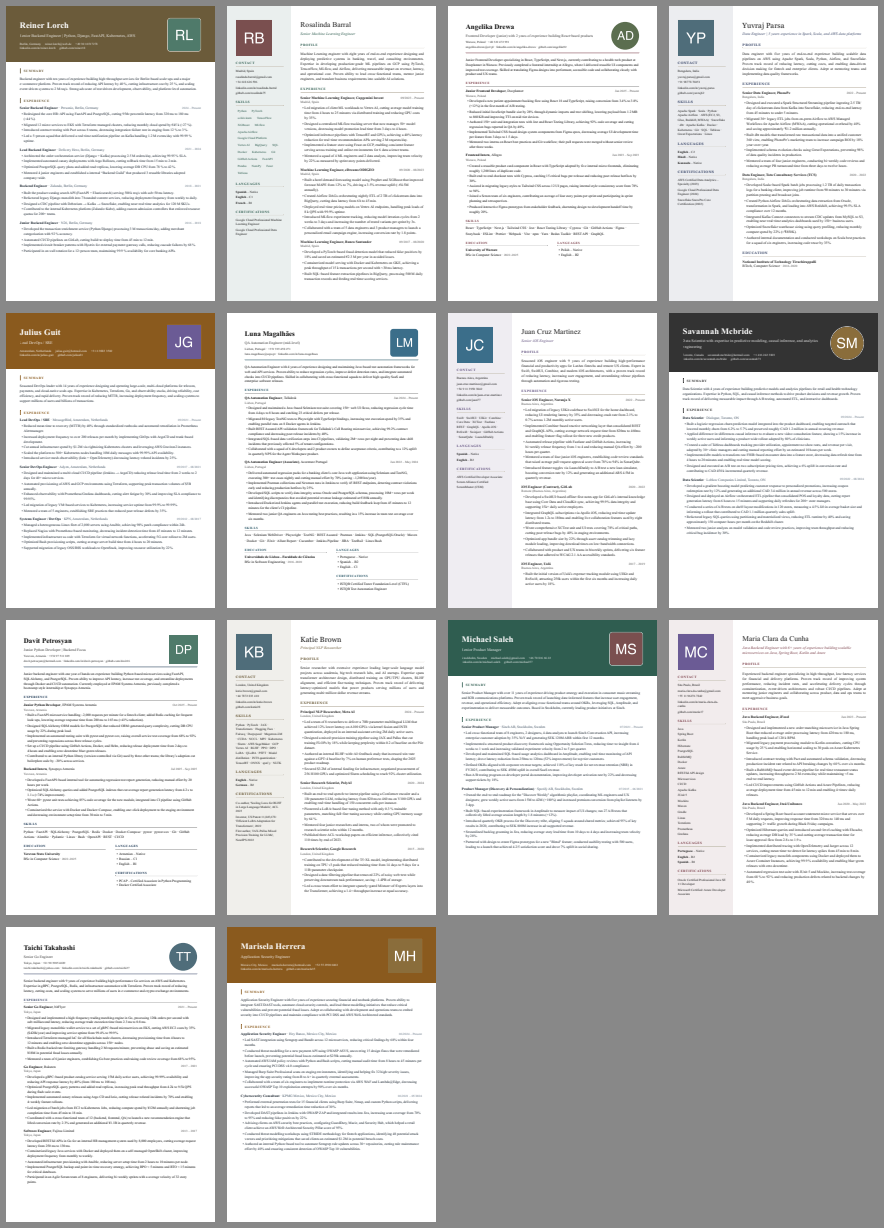

In [6]:
import pypdfium2 as pdfium
from PIL import Image


def first_page(path: Path, scale: float = 0.35) -> Image.Image:
    doc = pdfium.PdfDocument(str(path))
    img = doc[0].render(scale=scale).to_pil()
    doc.close()
    return img


thumbs = [first_page(p) for p in pdfs]
w, h = thumbs[0].size
cols = 4
rows = -(-len(thumbs) // cols)
sheet = Image.new("RGB", (cols * (w + 12), rows * (h + 12)), "#888")
for i, t in enumerate(thumbs):
    sheet.paste(t, ((i % cols) * (w + 12) + 6, (i // cols) * (h + 12) + 6))
display(sheet)

## 4. Индекс и поиск

### 4.1 Что такое эмбеддинг и косинусная близость

Эмбеддинг это превращение текста в вектор чисел. Модель обучена так, что тексты с похожим смыслом дают близкие векторы,
даже если слова не совпадают. Здесь используется `BAAI/bge-small-en-v1.5`: 384 числа на текст, запуск через
[fastembed](https://github.com/qdrant/fastembed) и ONNX Runtime, без PyTorch. Модель весит ~130 МБ, скачивается один раз,
дальше работает офлайн. Ключ не нужен.

Близость двух векторов измеряется косинусом угла между ними: 1.0 одно направление, 0 никакой связи. Ниже это видно на
четырёх фразах: две про машинное обучение дают 0.75 между собой, хотя общих слов у них почти нет, а тестирование и React
заметно ниже. У bge-small базовый уровень близости высокий (любые два английских текста дают ~0.4–0.5), поэтому смотреть
нужно на разницу, а не на абсолютное число. Это же причина, по которой порог «никто не подходит» будет жить в агенте, а не в индексе.

In [7]:
import numpy as np
from cv_screener.index.embeddings import FastEmbedder

phrases = [
    "trains deep learning models with PyTorch and deploys them to production",
    "machine learning engineer, neural networks, model serving",
    "automates regression tests with Selenium and Playwright",
    "builds React interfaces with TypeScript",
]
emb = FastEmbedder()
V = np.array(emb.embed(phrases))
print("shape:", V.shape, "→ 4 фразы × 384 числа\n")
cos = V @ V.T / (np.linalg.norm(V, axis=1)[:, None] * np.linalg.norm(V, axis=1)[None, :])
table([{"": phrases[i][:45], **{str(j): f"{cos[i, j]:.2f}" for j in range(len(phrases))}} for i in range(len(phrases))])

shape: (4, 384) → 4 фразы × 384 числа



,0,1,2,3
trains deep learning models with PyTorch and,1.00,0.75,0.57,0.47
"machine learning engineer, neural networks, m",0.75,1.00,0.61,0.47
automates regression tests with Selenium and,0.57,0.61,1.00,0.57
builds React interfaces with TypeScript,0.47,0.47,0.57,1.00


### 4.2 Что лежит в индексе

[ChromaDB](https://www.trychroma.com) это векторная база внутри процесса Python, данные в папке `data/chroma/`.
Без сервера и без Docker. Каждый кандидат превращается в один документ из четырёх частей:

```mermaid
flowchart TD
    C[Candidate] --> ST["search_text()<br/>имя, заголовок, саммари, навыки,<br/>языки, опыт с буллетами, образование"]
    ST --> E[bge-small] --> VEC[вектор 384 чисел<br/>для поиска по смыслу]
    C --> META["метаданные (только скаляры)<br/>seniority, role_family, country,<br/>years_experience"]
    C --> FL["булевы флаги<br/>lang_spanish: true<br/>skill_python: true<br/>skill_airflow: true"]
    C --> JS["json: полный профиль<br/>для get(id)"]
    VEC & META & FL & JS --> D[(документ Chroma)]
```

**Почему флаги.** Метаданные в Chroma только скаляры: строка, число, булево. Списка языков положить нельзя. Поэтому каждый
язык и навык становится отдельным булевым ключом, и фильтр «говорит по-испански» это `where={"lang_spanish": True}`.

**Нормализация навыков.** Модель пишет навыки как хочет: «Python 3.11», «Apache Airflow», «Python (Django)».
`skill_variants` из одной строки делает несколько ключей: полную, без версии, без скобок, по словам. Так фильтр
`skills=["Python"]` находит всех, как бы навык ни был записан.

In [8]:
from cv_screener.index.store import CandidateIndex, Filters

idx = CandidateIndex()
print("indexed:", idx.rebuild(cands), "candidates")


def show(hits):
    table([{"score": "" if h.score is None else f"{h.score:.3f}", "name": h.name, "headline": h.headline[:45],
            "level": h.seniority, "role": h.role_family, "country": h.country, "yrs": h.years_experience,
            "languages": h.languages} for h in hits] or [{"result": "no candidates match"}])

indexed: 14 candidates


In [9]:
from cv_screener.index.store import metadata_for

meta = metadata_for(cands[0])
scalars = {k: v for k, v in meta.items() if not k.startswith(("lang_", "skill_")) and k != "json"}
flags = sorted(k for k in meta if k.startswith(("lang_", "skill_")))
print(json.dumps(scalars, indent=2, ensure_ascii=False))
print(f"\n{len(flags)} флагов, например: {', '.join(flags[:12])} …")

{
  "id": "p01-reiner-lorch",
  "name": "Reiner Lorch",
  "headline": "Senior Backend Engineer | Python, Django, FastAPI, Kubernetes, AWS",
  "seniority": "senior",
  "role_family": "backend",
  "country": "germany",
  "country_display": "Germany",
  "city": "Berlin",
  "years_experience": 10,
  "languages": "German (Native), English (C1)",
  "skills": "Python 3.11, Django 4.2, FastAPI, PostgreSQL 15, Apache Kafka 3.6, Docker, Kubernetes (EKS, GKE), AWS (EC2, RDS, S3, Lambda, CloudWatch), Redis 7, Elasticsearch 8, GraphQL (Strawberry), Terraform, Prometheus & Grafana, GitLab CI/CD, Microservices architecture, Event‑driven design, Domain‑driven design, OpenTelemetry"
}

46 флагов, например: lang_english, lang_german, skill_apache, skill_apache_kafka, skill_apache_kafka_3_6, skill_architecture, skill_aws, skill_aws_ec2_rds_s3_lambda_cloudwatch, skill_cloudwatch, skill_design, skill_django, skill_django_4_2 …


### 4.3 Три режима одной функции

`search(query, filters, k)` покрывает всё. `Filters.to_where()` собирает условие Chroma: списки значений через `$in`,
минимум опыта через `$gte`, несколько условий через `$and`.

```mermaid
flowchart TD
    Q[search query, filters] --> HF{есть фильтр?}
    HF -->|да| W["to_where(): $in / $gte / $and"]
    HF -->|нет| W0[where = None]
    W & W0 --> HQ{есть текст запроса?}
    HQ -->|нет| GET["collection.get(where)<br/>точное совпадение, score пустой"]
    HQ -->|да| EMB[запрос → вектор] --> QRY["collection.query(vector, where, k)<br/>фильтр сужает, косинус ранжирует"]
    GET --> H[список Hit]
    QRY --> H
```

Плюс две служебные функции: `get(id)` достаёт полный профиль из поля `json`, `find_by_name(name)` ищет по имени нечётко
через `difflib` (коллекция маленькая, скан в памяти дешевле отдельного индекса). Ровно эти три функции потом дёргает агент,
и их же можно отдать наружу как MCP-тулы.

**По полям.** Кто говорит по-испански: фильтр по флагу `lang_spanish`, никакого ИИ. Обрати внимание на Michael Saleh с уровнем A2: флаг не различает уровни, решать, считать ли A2, будет агент.

In [10]:
show(idx.search(None, Filters(languages=["Spanish"]), k=10))

score,name,headline,level,role,country,yrs,languages
,Michael Saleh,Senior Product Manager,senior,product,Sweden,11,"Swedish (Native), English (C2), Spanish (A2)"
,Juan Cruz Martinez,Senior iOS Engineer,senior,mobile,Argentina,9,"Spanish (Native), English (B2)"
,Rosalinda Barral,Senior Machine Learning Engineer,senior,ml,Spain,8,"Spanish (Native), English (C1), French (B1)"
,Maria Clara da Cunha,Java Backend Engineer with 6+ years of experi,middle,backend,Brazil,6,"Portuguese (Native), English (B2), Spanish (B1)"
,Marisela Herrera,Application Security Engineer,middle,security,Mexico,5,"Spanish (Native), English (C1)"
,Luna Magalhães,QA Automation Engineer (mid-level),middle,qa,Portugal,4,"Portuguese (Native), Spanish (B2), English (C1)"


**По полям.** У кого Python в навыках: благодаря вариантам сюда попал и Reiner с записью «Python 3.11».

In [11]:
show(idx.search(None, Filters(skills=["Python"]), k=14))

score,name,headline,level,role,country,yrs,languages
,Katie Brown,Principal NLP Researcher,principal,ml,United Kingdom,15,"English (Native), German (B2)"
,Julius Guit,Lead DevOps / SRE,lead,devops,Netherlands,14,"Dutch (Native), English (C2)"
,Reiner Lorch,"Senior Backend Engineer | Python, Django, Fas",senior,backend,Germany,10,"German (Native), English (C1)"
,Rosalinda Barral,Senior Machine Learning Engineer,senior,ml,Spain,8,"Spanish (Native), English (C1), French (B1)"
,Marisela Herrera,Application Security Engineer,middle,security,Mexico,5,"Spanish (Native), English (C1)"
,Yuvraj Parsa,"Data Engineer | 5 years experience in Spark,",middle,data,India,5,"English (C2), Hindi (Native), Kannada (Native)"
,Savannah Mcbride,Data Scientist with expertise in predictive m,middle,data-science,Canada,4,"English (Native), French (C1), Mandarin (B1)"
,Davit Petrosyan,Junior Python Developer | Backend Focus,junior,backend,Armenia,1,"Armenian (Native), Russian (C1), English (B1)"


**По смыслу.** «Best fit for a senior ML role»: слов «senior ML» в резюме нет, но векторы Rosalinda и Katie ближе всех, а бэкендеры с Python идут с заметным отрывом.

In [12]:
show(idx.search("senior machine learning engineer, deep learning, model deployment", k=5))

score,name,headline,level,role,country,yrs,languages
0.794,Rosalinda Barral,Senior Machine Learning Engineer,senior,ml,Spain,8,"Spanish (Native), English (C1), French (B1)"
0.726,Katie Brown,Principal NLP Researcher,principal,ml,United Kingdom,15,"English (Native), German (B2)"
0.674,Reiner Lorch,"Senior Backend Engineer | Python, Django, Fas",senior,backend,Germany,10,"German (Native), English (C1)"
0.665,Yuvraj Parsa,"Data Engineer | 5 years experience in Spark,",middle,data,India,5,"English (C2), Hindi (Native), Kannada (Native)"
0.647,Taichi Takahashi,Senior Go Engineer,senior,backend,Japan,9,"Japanese (Native), English (B2)"


**Гибрид.** Тот же смысл, но только уровни senior и выше: фильтр отсекает middle и junior до ранжирования.

In [13]:
show(idx.search("machine learning research and production ML systems",
                Filters(seniority=["senior", "lead", "principal"]), k=5))

score,name,headline,level,role,country,yrs,languages
0.715,Rosalinda Barral,Senior Machine Learning Engineer,senior,ml,Spain,8,"Spanish (Native), English (C1), French (B1)"
0.666,Katie Brown,Principal NLP Researcher,principal,ml,United Kingdom,15,"English (Native), German (B2)"
0.595,Reiner Lorch,"Senior Backend Engineer | Python, Django, Fas",senior,backend,Germany,10,"German (Native), English (C1)"
0.576,Michael Saleh,Senior Product Manager,senior,product,Sweden,11,"Swedish (Native), English (C2), Spanish (A2)"
0.570,Julius Guit,Lead DevOps / SRE,lead,devops,Netherlands,14,"Dutch (Native), English (C2)"


**Пусто.** Иврита в датасете нет, индекс честно возвращает пустой список. Агент на этом построит ответ «никто не подходит». И пример нечёткого поиска по имени.

In [14]:
show(idx.search(None, Filters(languages=["Hebrew"])))
print(idx.find_by_name("Katie"))

result
no candidates match


[Hit(id='p10-katie-brown', name='Katie Brown', headline='Principal NLP Researcher', seniority='principal', role_family='ml', country='United Kingdom', years_experience=15, languages='English (Native), German (B2)', score=1.0)]


### 4.4 Как это тестируется без сети

В тестах модель bge-small не нужна: там проверяется не качество смысла, а сантехника: флаги, фильтры, ранжирование,
`get`, перестройка. Для этого есть `HashEmbedder`: каждое слово хэшируется в одну из 64 позиций вектора, общие слова дают
близкие векторы. Смысла он не понимает, зато детерминирован и мгновенен. `CandidateIndex` принимает эмбеддер в конструкторе:
тесты подставляют хэш, продакшн берёт bge по умолчанию. Тот же приём повторится в агенте с фейковой LLM.

## 5. Агент — фаза 4

## 6. Эвалы — фаза 5